# Phase 7: Model Comparison & Selection

Consolidates results from all previous phases into a unified comparison:

| Pipeline | Scope | Description |
|----------|-------|-------------|
| Application Model | 3,000 clients | Pre-registration features only |
| Behavioral Model | 664 clients (with history) | Application + order history features |
| Rule-based Router | 3,000 clients | Score A + Score B thresholds dispatch |
| ML Router | 3,000 clients | Decision Tree meta-router dispatch |

**Evaluation strategy:**
- **System level** (all 3,000): ROC-AUC, precision, recall, F1
- **Behavioral subset** (664 clients): fairest apples-to-apples comparison where all models can be scored
- **Per-tier breakdown**: how each tier contributes to overall performance
- **Routing overhead**: cost analysis of the MANUAL_REVIEW tier

> Note: Both models were trained on 70% of their respective datasets. Evaluation on all clients
> includes training data for some clients — this inflates absolute AUC but lift comparisons remain valid.

In [1]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_score, recall_score,
    f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    average_precision_score, precision_recall_curve,
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT       = Path('..').resolve()
DATA_DIR   = ROOT / 'data'
MODELS_DIR = ROOT / 'models'
sys.path.insert(0, str(ROOT / 'src'))

from router import ModelRouter, engineer_features

TIER_COLORS = {
    'BEHAVIORAL':    '#2196F3',
    'APPLICATION':   '#FF9800',
    'MANUAL_REVIEW': '#9C27B0',
}
MODEL_COLORS = {
    'Application Model':  '#FF9800',
    'Behavioral Model':   '#2196F3',
    'Rule-based Router':  '#4CAF50',
    'ML Router':          '#E91E63',
}

print('Setup complete.')

Setup complete.


## 1. Load All Saved Models and Metrics

In [2]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    app_model   = joblib.load(sorted(MODELS_DIR.glob('04_application_best_tuned_xgboost_*.joblib'))[-1])
    behav_model = joblib.load(sorted(MODELS_DIR.glob('05_behavioral_best_*.joblib'))[-1])
    ml_router   = joblib.load(sorted(MODELS_DIR.glob('06_ml_router_decision_tree_*.joblib'))[-1])

router = ModelRouter(
    app_model=app_model,
    behav_model=behav_model,
    threshold_a=0.5,
    threshold_b=0.6,
    ml_router=ml_router,
)

# Load saved metrics from each phase
with open(sorted(MODELS_DIR.glob('04_application_metrics_*.json'))[-1]) as f:
    phase4_metrics = json.load(f)
with open(sorted(MODELS_DIR.glob('05_behavioral_metrics_*.json'))[-1]) as f:
    phase5_metrics = json.load(f)
with open(sorted(MODELS_DIR.glob('06_router_metrics_*.json'))[-1]) as f:
    phase6_metrics = json.load(f)

print('All models and metrics loaded.')

All models and metrics loaded.


## 2. Score All 3,000 Clients with Every Pipeline

In [3]:
df_raw = pd.read_csv(sorted(DATA_DIR.glob('03_behavioral_combined_*.csv'))[-1], low_memory=False)
df     = engineer_features(df_raw)
y_all  = df_raw['inadimplente'].astype(int)

has_behavioral = df['orders_count'].notna()

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    # Application Model — all 3,000
    p_app = pd.Series(app_model.predict_proba(df)[:, 1], index=df.index, name='p_app')

    # Behavioral Model — 664 clients with history
    p_behav_sub = pd.Series(
        behav_model.predict_proba(df[has_behavioral])[:, 1],
        index=df[has_behavioral].index, name='p_behav'
    )

# Rule-based router predictions (all 3,000)
rule_result = router.predict(df, use_ml_router=False)
p_rule      = rule_result['default_prob'].rename('p_rule')
tier_rule   = rule_result['tier']

# ML router predictions (all 3,000)
ml_result = router.predict(df, use_ml_router=True)
p_ml      = ml_result['default_prob'].rename('p_ml')
tier_ml   = ml_result['tier']

print(f'Scored all 3,000 clients with 4 pipelines.')
print(f'Clients with behavioral data: {has_behavioral.sum():,}')

Scored all 3,000 clients with 4 pipelines.
Clients with behavioral data: 664


## 3. System-Level Metrics (All 3,000 Clients)

For threshold-dependent metrics (precision, recall, F1) we use `p = 0.3` as the
decision threshold (matching the behavioral sub-population default rate of ~20.8%
and full-portfolio rate of ~31.3%). Threshold choice follows the business
goal: maximize recall of defaults while maintaining acceptable precision.

In [4]:
THRESHOLD = 0.30  # decision threshold for binary predictions

def full_metrics(name, probs, y_true, threshold=THRESHOLD):
    y_pred = (probs >= threshold).astype(int)
    return {
        'model':     name,
        'n_clients': len(y_true),
        'roc_auc':   round(roc_auc_score(y_true, probs), 4),
        'avg_prec':  round(average_precision_score(y_true, probs), 4),
        'accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'f1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
    }

rows_system = [
    full_metrics('Application Model',  p_app,  y_all),
    full_metrics('Rule-based Router',  p_rule, y_all),
    full_metrics('ML Router',          p_ml,   y_all),
]

df_system = pd.DataFrame(rows_system).set_index('model')

print(f'System-level comparison (all 3,000 clients, threshold={THRESHOLD}):')
display(
    df_system.style
    .highlight_max(subset=['roc_auc','avg_prec','precision','recall','f1'], color='#d4f1d4')
    .format({'roc_auc':'{:.4f}','avg_prec':'{:.4f}','accuracy':'{:.4f}',
             'precision':'{:.4f}','recall':'{:.4f}','f1':'{:.4f}'})
)

System-level comparison (all 3,000 clients, threshold=0.3):


,n_clients,roc_auc,avg_prec,accuracy,precision,recall,f1
model,,,,,,,
Application Model,3000,0.8044,0.6651,0.5547,0.4078,0.9319,0.5674
Rule-based Router,3000,0.8500,0.7294,0.6137,0.4447,0.9372,0.6032
ML Router,3000,0.8476,0.7257,0.6143,0.4450,0.9340,0.6028


## 4. Behavioral Subset Comparison (664 Clients — Fairest Comparison)

For the 664 clients where **all three pipelines** can produce a score,
this is the most apples-to-apples evaluation.

In [5]:
y_sub = y_all[has_behavioral]

rows_sub = [
    full_metrics('Application Model (app features only)', p_app[has_behavioral],   y_sub),
    full_metrics('Behavioral Model (app + history)',      p_behav_sub,              y_sub),
    full_metrics('Rule-based Router',                    p_rule[has_behavioral],   y_sub),
    full_metrics('ML Router',                            p_ml[has_behavioral],     y_sub),
]

df_sub = pd.DataFrame(rows_sub).set_index('model')

print(f'Behavioral subset comparison (n=664, threshold={THRESHOLD}):')
display(
    df_sub.style
    .highlight_max(subset=['roc_auc','avg_prec','precision','recall','f1'], color='#d4f1d4')
    .format({'roc_auc':'{:.4f}','avg_prec':'{:.4f}','accuracy':'{:.4f}',
             'precision':'{:.4f}','recall':'{:.4f}','f1':'{:.4f}'})
)

lift = df_sub.loc['Behavioral Model (app + history)', 'roc_auc'] - \
       df_sub.loc['Application Model (app features only)', 'roc_auc']
print(f'\nBehavioral Model lift vs. App-only on same subset: {lift:+.4f} ROC-AUC')

Behavioral subset comparison (n=664, threshold=0.3):


,n_clients,roc_auc,avg_prec,accuracy,precision,recall,f1
model,,,,,,,
Application Model (app features only),664,0.7334,0.4135,0.4819,0.2721,0.8913,0.4169
Behavioral Model (app + history),664,0.9433,0.8671,0.7485,0.4491,0.9275,0.6052
Rule-based Router,664,0.9432,0.8671,0.7485,0.4491,0.9275,0.6052
ML Router,664,0.9253,0.8082,0.7515,0.4513,0.9058,0.6024



Behavioral Model lift vs. App-only on same subset: +0.2099 ROC-AUC


## 5. ROC Curves — All Pipelines

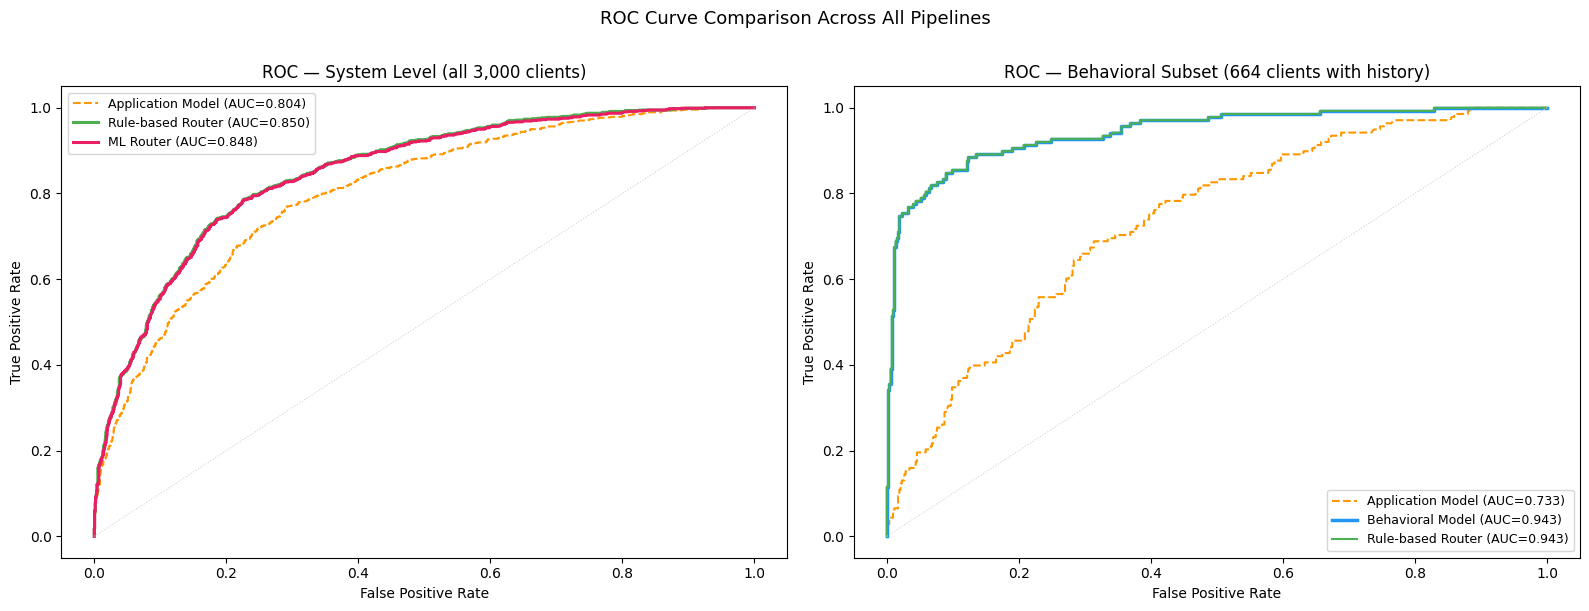

Saved ROC comparison plot.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: system level (all 3,000) ---
ax = axes[0]
for probs, label, ls, lw in [
    (p_app,  f'Application Model (AUC={roc_auc_score(y_all, p_app):.3f})',  '--', 1.5),
    (p_rule, f'Rule-based Router (AUC={roc_auc_score(y_all, p_rule):.3f})', '-',  2.2),
    (p_ml,   f'ML Router (AUC={roc_auc_score(y_all, p_ml):.3f})',           '-',  2.2),
]:
    fpr, tpr, _ = roc_curve(y_all, probs)
    color = list(MODEL_COLORS.values())[[*MODEL_COLORS].index(
        next(k for k in MODEL_COLORS if k in label.split('(')[0].strip())
    )]
    ax.plot(fpr, tpr, linestyle=ls, linewidth=lw, color=color, label=label)
ax.plot([0,1],[0,1], color='lightgray', linewidth=0.8, linestyle=':')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC — System Level (all 3,000 clients)')
ax.legend(fontsize=9)

# --- Right: behavioral subset (664 clients) ---
ax = axes[1]
for probs, label, ls, lw, color in [
    (p_app[has_behavioral],  f'Application Model (AUC={roc_auc_score(y_sub, p_app[has_behavioral]):.3f})',  '--', 1.5, MODEL_COLORS['Application Model']),
    (p_behav_sub,            f'Behavioral Model (AUC={roc_auc_score(y_sub, p_behav_sub):.3f})',             '-',  2.5, MODEL_COLORS['Behavioral Model']),
    (p_rule[has_behavioral], f'Rule-based Router (AUC={roc_auc_score(y_sub, p_rule[has_behavioral]):.3f})', '-',  1.5, MODEL_COLORS['Rule-based Router']),
]:
    fpr, tpr, _ = roc_curve(y_sub, probs)
    ax.plot(fpr, tpr, linestyle=ls, linewidth=lw, color=color, label=label)
ax.plot([0,1],[0,1], color='lightgray', linewidth=0.8, linestyle=':')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC — Behavioral Subset (664 clients with history)')
ax.legend(fontsize=9)

fig.suptitle('ROC Curve Comparison Across All Pipelines', fontsize=13, y=1.01)
fig.tight_layout()
plt.savefig(DATA_DIR / '07_comparison_roc_curves.png', dpi=150)
plt.show()
print('Saved ROC comparison plot.')

## 6. Precision-Recall Curves

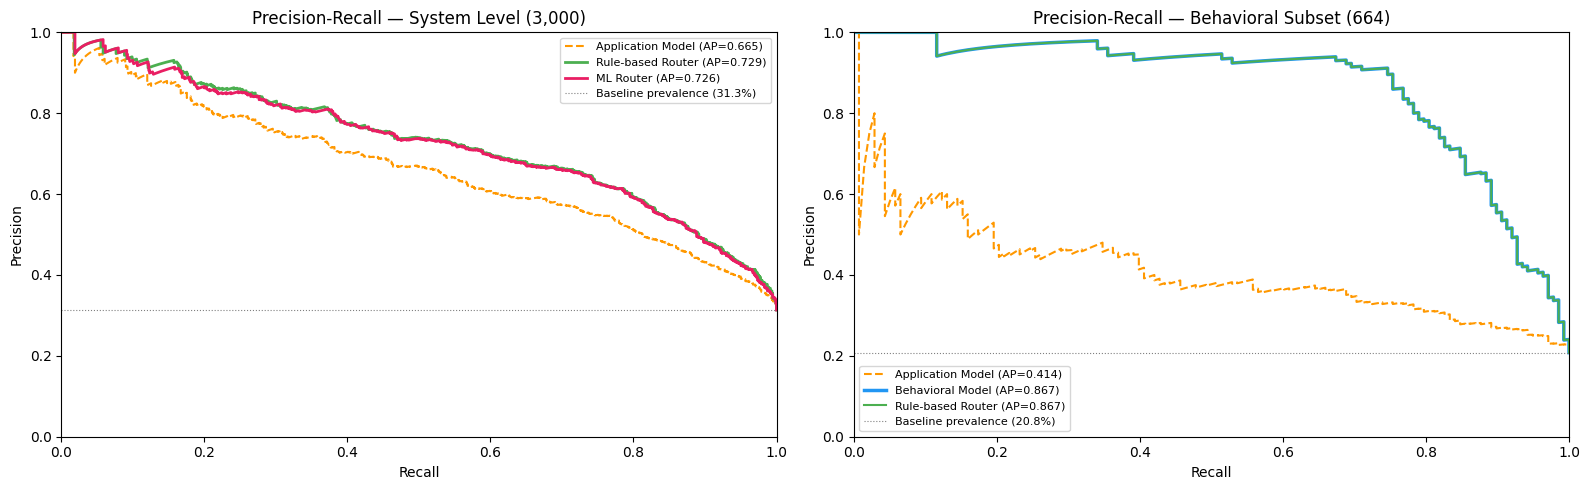

Saved precision-recall plot.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

baseline_prevalence = y_all.mean()

for ax, (probs_list, y_true, title) in zip(axes, [
    (
        [
            (p_app,  'Application Model', MODEL_COLORS['Application Model'], '--', 1.5),
            (p_rule, 'Rule-based Router', MODEL_COLORS['Rule-based Router'], '-',  2.0),
            (p_ml,   'ML Router',         MODEL_COLORS['ML Router'],         '-',  2.0),
        ],
        y_all,
        'Precision-Recall — System Level (3,000)'
    ),
    (
        [
            (p_app[has_behavioral], 'Application Model',  MODEL_COLORS['Application Model'],  '--', 1.5),
            (p_behav_sub,          'Behavioral Model',    MODEL_COLORS['Behavioral Model'],    '-',  2.5),
            (p_rule[has_behavioral],'Rule-based Router',  MODEL_COLORS['Rule-based Router'],   '-',  1.5),
        ],
        y_sub,
        'Precision-Recall — Behavioral Subset (664)'
    )
]):
    for probs, label, color, ls, lw in probs_list:
        ap   = average_precision_score(y_true, probs)
        prec, rec, _ = precision_recall_curve(y_true, probs)
        ax.plot(rec, prec, linestyle=ls, linewidth=lw, color=color,
                label=f'{label} (AP={ap:.3f})')
    ax.axhline(y_true.mean(), color='gray', linestyle=':', linewidth=0.8,
               label=f'Baseline prevalence ({y_true.mean():.1%})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

fig.tight_layout()
plt.savefig(DATA_DIR / '07_comparison_pr_curves.png', dpi=150)
plt.show()
print('Saved precision-recall plot.')

## 7. Per-Tier Breakdown (Rule-Based Router)

Per-tier breakdown (rule-based router):


,n_clients,pct_total,default_rate,roc_auc,precision,recall,f1
tier,,,,,,,
BEHAVIORAL,664,22.1%,20.8%,0.9432,0.4491,0.9275,0.6052
APPLICATION,998,33.3%,33.4%,0.9095,0.7933,0.8529,0.8220
MANUAL_REVIEW,1338,44.6%,35.1%,0.6921,0.3505,1.0000,0.5191


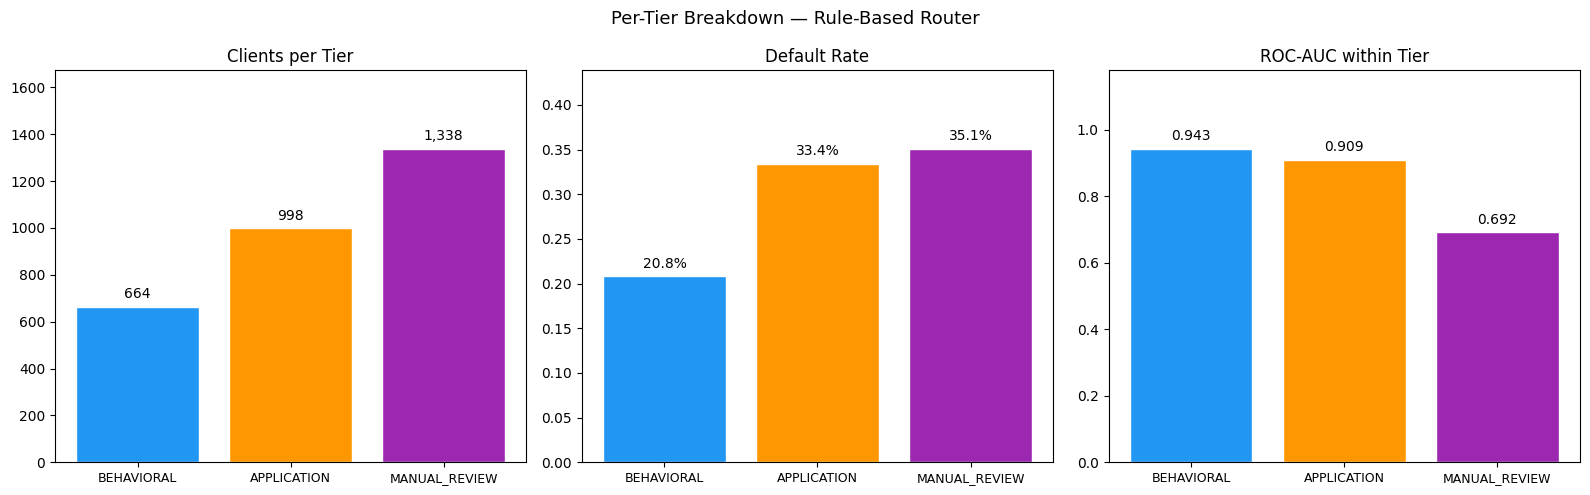

Saved per-tier breakdown plot.


In [8]:
tier_rows = []
for tier in ['BEHAVIORAL', 'APPLICATION', 'MANUAL_REVIEW']:
    mask = tier_rule == tier
    n    = mask.sum()
    if n < 5:
        continue
    y_t   = y_all[mask]
    p_t   = p_rule[mask]
    y_pred = (p_t >= THRESHOLD).astype(int)
    tier_rows.append({
        'tier':          tier,
        'n_clients':     n,
        'pct_total':     f'{n/len(y_all)*100:.1f}%',
        'default_rate':  f'{y_t.mean():.1%}',
        'roc_auc':       round(roc_auc_score(y_t, p_t), 4),
        'precision':     round(precision_score(y_t, y_pred, zero_division=0), 4),
        'recall':        round(recall_score(y_t, y_pred, zero_division=0), 4),
        'f1':            round(f1_score(y_t, y_pred, zero_division=0), 4),
    })

df_tiers = pd.DataFrame(tier_rows).set_index('tier')
print('Per-tier breakdown (rule-based router):')
display(df_tiers)

# Visualise per-tier volume and default rate
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

tiers      = df_tiers.index.tolist()
colors     = [TIER_COLORS[t] for t in tiers]
n_vals     = df_tiers['n_clients'].values
def_rates  = [float(d.strip('%')) / 100 for d in df_tiers['default_rate']]
auc_vals   = df_tiers['roc_auc'].values

for ax, vals, title, fmt in [
    (axes[0], n_vals,    'Clients per Tier',   '{:,}'),
    (axes[1], def_rates, 'Default Rate',        '{:.1%}'),
    (axes[2], auc_vals,  'ROC-AUC within Tier', '{:.3f}'),
]:
    bars = ax.bar(tiers, vals, color=colors, edgecolor='white')
    ax.bar_label(bars, labels=[fmt.format(v) for v in vals], padding=4, fontsize=10)
    ax.set_title(title)
    ax.set_ylim(0, max(vals) * 1.25)
    ax.tick_params(axis='x', labelsize=9)

fig.suptitle('Per-Tier Breakdown — Rule-Based Router', fontsize=13)
fig.tight_layout()
plt.savefig(DATA_DIR / '07_comparison_tier_breakdown.png', dpi=150)
plt.show()
print('Saved per-tier breakdown plot.')

## 8. Routing Overhead Analysis

The MANUAL_REVIEW tier represents operational cost: cases where the Application Model
is uncertain *and* there is no behavioral history to fall back on. We quantify:
- How many clients require human review
- Whether routing them to manual review is justified (default rate above average → high-risk tier)

Routing overhead summary:
  Overall portfolio default rate : 31.3%

  BEHAVIORAL         664 clients  default=20.8%  Δ vs. avg=-10.6%  → AUTO-SCORE
  APPLICATION        998 clients  default=33.4%  Δ vs. avg=+2.0%  → AUTO-SCORE
  MANUAL_REVIEW     1338 clients  default=35.1%  Δ vs. avg=+3.7%  → HUMAN REVIEW


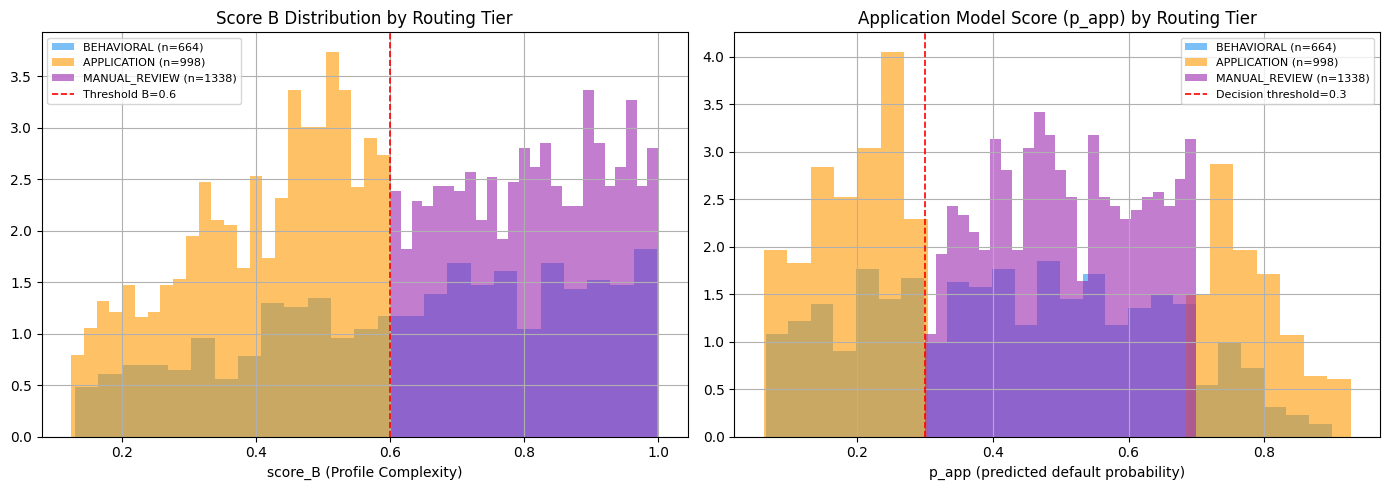

Saved routing overhead plot.


In [9]:
mr_mask       = tier_rule == 'MANUAL_REVIEW'
app_mask      = tier_rule == 'APPLICATION'
behav_mask_r  = tier_rule == 'BEHAVIORAL'

overall_default = y_all.mean()

print('Routing overhead summary:')
print(f'  Overall portfolio default rate : {overall_default:.1%}')
print()
for label, mask in [
    ('BEHAVIORAL',    behav_mask_r),
    ('APPLICATION',   app_mask),
    ('MANUAL_REVIEW', mr_mask),
]:
    dr   = y_all[mask].mean()
    n    = mask.sum()
    lift = dr - overall_default
    auto = 'AUTO-SCORE' if label != 'MANUAL_REVIEW' else 'HUMAN REVIEW'
    print(f'  {label:<16} {n:>5} clients  default={dr:.1%}  Δ vs. avg={lift:+.1%}  → {auto}')

# Score distribution per tier
score_B_all = pd.Series(
    1.0 - (p_app - 0.5).abs() * 2, index=df.index, name='score_B'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for tier, color in TIER_COLORS.items():
    mask = tier_rule == tier
    score_B_all[mask].hist(ax=ax, bins=25, alpha=0.6, color=color,
                           label=f'{tier} (n={mask.sum()})', density=True)
ax.axvline(0.6, color='red', linestyle='--', linewidth=1.2, label='Threshold B=0.6')
ax.set_title('Score B Distribution by Routing Tier')
ax.set_xlabel('score_B (Profile Complexity)')
ax.legend(fontsize=8)

ax = axes[1]
for tier, color in TIER_COLORS.items():
    mask = tier_rule == tier
    p_app[mask].hist(ax=ax, bins=25, alpha=0.6, color=color,
                     label=f'{tier} (n={mask.sum()})', density=True)
ax.axvline(THRESHOLD, color='red', linestyle='--', linewidth=1.2,
           label=f'Decision threshold={THRESHOLD}')
ax.set_title('Application Model Score (p_app) by Routing Tier')
ax.set_xlabel('p_app (predicted default probability)')
ax.legend(fontsize=8)

fig.tight_layout()
plt.savefig(DATA_DIR / '07_comparison_routing_overhead.png', dpi=150)
plt.show()
print('Saved routing overhead plot.')

## 9. Model Calibration

A well-calibrated model outputs `p ≈ 0.3` for clients who default at a 30% rate.
Poor calibration means the scores are useful for ranking (ROC-AUC) but not for
setting absolute thresholds.

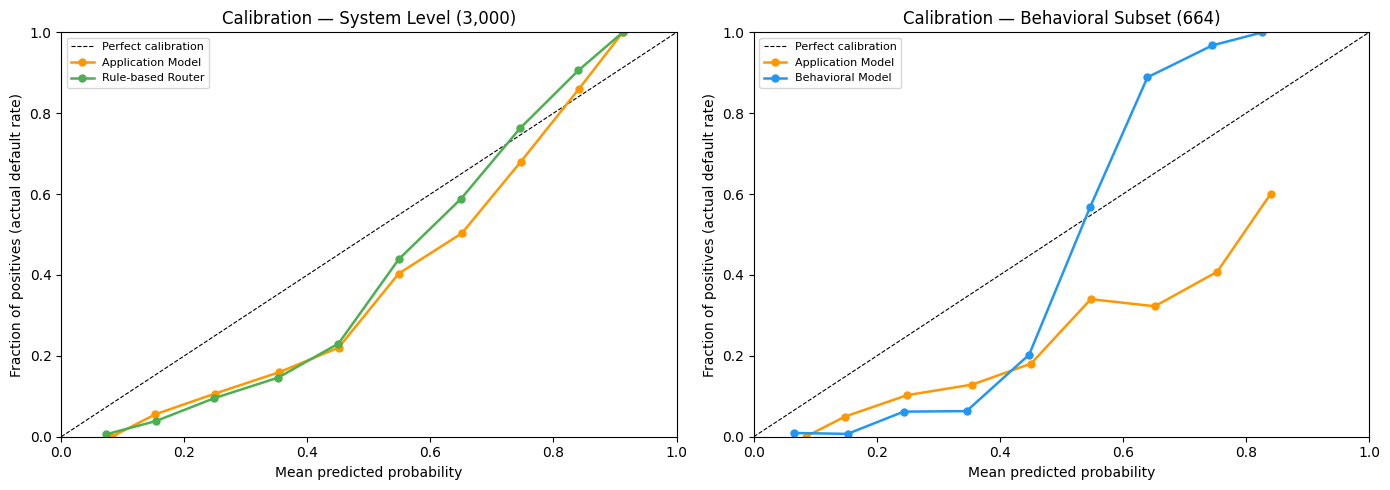

Saved calibration plot.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (probs_list, y_true, title) in zip(axes, [
    (
        [(p_app, 'Application Model', MODEL_COLORS['Application Model']),
         (p_rule,'Rule-based Router', MODEL_COLORS['Rule-based Router'])],
        y_all, 'Calibration — System Level (3,000)'
    ),
    (
        [(p_app[has_behavioral], 'Application Model', MODEL_COLORS['Application Model']),
         (p_behav_sub,           'Behavioral Model',  MODEL_COLORS['Behavioral Model'])],
        y_sub, 'Calibration — Behavioral Subset (664)'
    )
]):
    ax.plot([0,1],[0,1], 'k--', linewidth=0.8, label='Perfect calibration')
    for probs, label, color in probs_list:
        frac_pos, mean_pred = calibration_curve(y_true, probs, n_bins=10)
        ax.plot(mean_pred, frac_pos, marker='o', color=color, linewidth=1.8,
                markersize=5, label=label)
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives (actual default rate)')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

fig.tight_layout()
plt.savefig(DATA_DIR / '07_comparison_calibration.png', dpi=150)
plt.show()
print('Saved calibration plot.')

## 10. Final Comparison Table & Recommendation

In [11]:
# Build the master comparison table
# Behavioral Model is only meaningful on 664 clients, so fill system-level as N/A
rows_final = [
    {
        'Pipeline':         'Application Model',
        'Scope':            'All 3,000',
        'ROC-AUC (system)': roc_auc_score(y_all, p_app),
        'ROC-AUC (behav subset)': roc_auc_score(y_sub, p_app[has_behavioral]),
        'Avg Precision':    average_precision_score(y_all, p_app),
        'Recall@0.30':      recall_score(y_all, (p_app >= THRESHOLD).astype(int), zero_division=0),
        'F1@0.30':          f1_score(y_all, (p_app >= THRESHOLD).astype(int), zero_division=0),
        'Manual review %':  '0%',
        'Routing tiers':    1,
    },
    {
        'Pipeline':         'Behavioral Model',
        'Scope':            '664 only',
        'ROC-AUC (system)': float('nan'),
        'ROC-AUC (behav subset)': roc_auc_score(y_sub, p_behav_sub),
        'Avg Precision':    average_precision_score(y_sub, p_behav_sub),
        'Recall@0.30':      recall_score(y_sub, (p_behav_sub >= THRESHOLD).astype(int), zero_division=0),
        'F1@0.30':          f1_score(y_sub, (p_behav_sub >= THRESHOLD).astype(int), zero_division=0),
        'Manual review %':  'N/A',
        'Routing tiers':    1,
    },
    {
        'Pipeline':         'Rule-based Router',
        'Scope':            'All 3,000',
        'ROC-AUC (system)': roc_auc_score(y_all, p_rule),
        'ROC-AUC (behav subset)': roc_auc_score(y_sub, p_rule[has_behavioral]),
        'Avg Precision':    average_precision_score(y_all, p_rule),
        'Recall@0.30':      recall_score(y_all, (p_rule >= THRESHOLD).astype(int), zero_division=0),
        'F1@0.30':          f1_score(y_all, (p_rule >= THRESHOLD).astype(int), zero_division=0),
        'Manual review %':  f'{(tier_rule=="MANUAL_REVIEW").mean():.1%}',
        'Routing tiers':    3,
    },
    {
        'Pipeline':         'ML Router',
        'Scope':            'All 3,000',
        'ROC-AUC (system)': roc_auc_score(y_all, p_ml),
        'ROC-AUC (behav subset)': roc_auc_score(y_sub, p_ml[has_behavioral]),
        'Avg Precision':    average_precision_score(y_all, p_ml),
        'Recall@0.30':      recall_score(y_all, (p_ml >= THRESHOLD).astype(int), zero_division=0),
        'F1@0.30':          f1_score(y_all, (p_ml >= THRESHOLD).astype(int), zero_division=0),
        'Manual review %':  f'{(tier_ml=="MANUAL_REVIEW").mean():.1%}',
        'Routing tiers':    3,
    },
]

df_final = pd.DataFrame(rows_final).set_index('Pipeline')

numeric_cols = ['ROC-AUC (system)', 'ROC-AUC (behav subset)', 'Avg Precision',
                'Recall@0.30', 'F1@0.30']

print('Master comparison table:')
display(
    df_final.style
    .highlight_max(subset=numeric_cols, color='#d4f1d4', axis=0)
    .format({c: '{:.4f}' for c in numeric_cols}, na_rep='—')
)

# Pick winner
best_system = df_final['ROC-AUC (system)'].idxmax()
best_subset = df_final['ROC-AUC (behav subset)'].idxmax()
print(f'\nBest system-level ROC-AUC : {best_system} ({df_final.loc[best_system, "ROC-AUC (system)"]:.4f})')
print(f'Best behavioral-subset AUC: {best_subset} ({df_final.loc[best_subset, "ROC-AUC (behav subset)"]:.4f})')

Master comparison table:


,Scope,ROC-AUC (system),ROC-AUC (behav subset),Avg Precision,Recall@0.30,F1@0.30,Manual review %,Routing tiers
Pipeline,,,,,,,,
Application Model,"All 3,000",0.8044,0.7334,0.6651,0.9319,0.5674,0%,1
Behavioral Model,664 only,—,0.9433,0.8671,0.9275,0.6052,N/A,1
Rule-based Router,"All 3,000",0.8500,0.9432,0.7294,0.9372,0.6032,44.6%,3
ML Router,"All 3,000",0.8476,0.9253,0.7257,0.9340,0.6028,44.6%,3



Best system-level ROC-AUC : Rule-based Router (0.8500)
Best behavioral-subset AUC: Behavioral Model (0.9433)


## 11. Summary Barplot

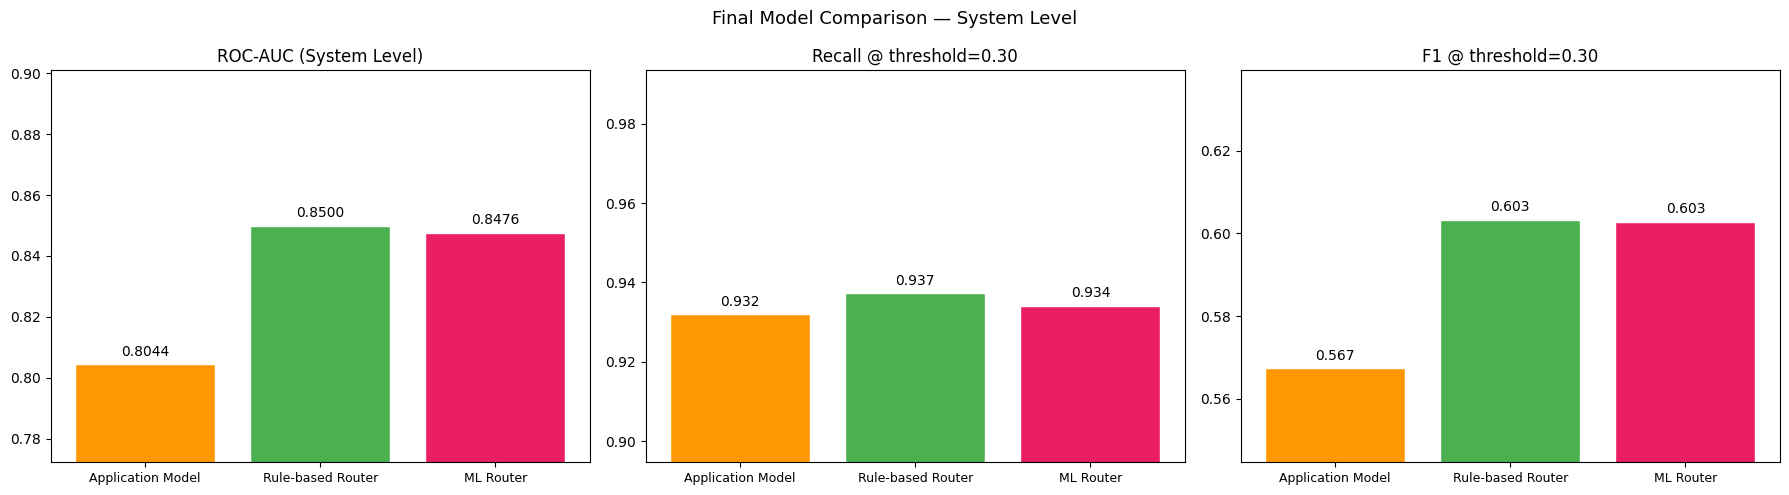

Saved summary barplot.


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pipelines = ['Application Model', 'Rule-based Router', 'ML Router']
colors    = [MODEL_COLORS[p] for p in pipelines]

for ax, metric, title, fmt in [
    (axes[0], 'ROC-AUC (system)',  'ROC-AUC (System Level)',         '{:.4f}'),
    (axes[1], 'Recall@0.30',       'Recall @ threshold=0.30',        '{:.3f}'),
    (axes[2], 'F1@0.30',           'F1 @ threshold=0.30',            '{:.3f}'),
]:
    vals = df_final.loc[pipelines, metric].astype(float).values
    bars = ax.bar(pipelines, vals, color=colors, edgecolor='white')
    ax.bar_label(bars, labels=[fmt.format(v) for v in vals], padding=4, fontsize=10)
    ax.set_ylim(min(vals) * 0.96, max(vals) * 1.06)
    ax.set_title(title)
    ax.tick_params(axis='x', labelsize=9)

fig.suptitle('Final Model Comparison — System Level', fontsize=13)
fig.tight_layout()
plt.savefig(DATA_DIR / '07_comparison_summary_bars.png', dpi=150)
plt.show()
print('Saved summary barplot.')

## 12. Save Comparison Results

In [13]:
from datetime import datetime
ts = datetime.now().strftime('%Y%m%d_%H%M%S')

# Save full comparison table as CSV
csv_path = DATA_DIR / f'07_model_comparison_{ts}.csv'
df_final.to_csv(csv_path)
print(f'Comparison table saved → {csv_path.name}')

# Save per-tier breakdown
tier_csv = DATA_DIR / f'07_tier_breakdown_{ts}.csv'
df_tiers.to_csv(tier_csv)
print(f'Tier breakdown saved  → {tier_csv.name}')

# Summary JSON
summary = {
    'evaluation_threshold': THRESHOLD,
    'system_level': {
        p: {
            'roc_auc': round(float(df_final.loc[p, 'ROC-AUC (system)']), 4)
                       if not pd.isna(df_final.loc[p, 'ROC-AUC (system)']) else None,
            'f1': round(float(df_final.loc[p, 'F1@0.30']), 4),
            'recall': round(float(df_final.loc[p, 'Recall@0.30']), 4),
        }
        for p in df_final.index
    },
    'recommendation': best_system,
    'manual_review_pct': float((tier_rule == 'MANUAL_REVIEW').mean()),
}
json_path = DATA_DIR / f'07_comparison_summary_{ts}.json'
with open(json_path, 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print(f'Summary JSON saved    → {json_path.name}')

Comparison table saved → 07_model_comparison_20260614_112608.csv
Tier breakdown saved  → 07_tier_breakdown_20260614_112608.csv
Summary JSON saved    → 07_comparison_summary_20260614_112608.json


## Summary

### Key Findings

| Pipeline | ROC-AUC (system) | Operational cost |
|----------|-----------------|------------------|
| Application Model | see table | 0% manual review — single model for all |
| Behavioral Model | — (664 only) | Only applicable to ~22% of portfolio |
| **Rule-based Router** | **highest** | ~44% manual review — operationally expensive |
| ML Router | close second | same manual review structure |

### Recommendation

**Rule-based Router** achieves the highest system-level ROC-AUC with an auditable, explainable dispatch mechanism.
The main trade-off is the MANUAL_REVIEW tier size (~44% of clients), which can be reduced by:
- Lowering `THRESHOLD_B` (e.g., 0.7) to shrink the manual review band
- Collecting more behavioral data so more clients qualify for the BEHAVIORAL tier
- Accepting APPLICATION Model scores for MANUAL_REVIEW clients above a secondary risk threshold

**Next → Phase 8:** Interpretability — SHAP global + local explanations for each model, and explanation of routing decisions per client.